<h1><center><b> Intervalos de Confianza </b></center></h1>

Los intervalos de confianza son estimadores que se realiza para **la inferencia estaditica** *(es la generalizacion de la poblacion apartir de una muestra)*. A diferencia de los estimadores puntuales, estos tiene el objetivo de establecer un rango en donde el parametro poblacional tome los valores *(lo cual es mas seguro que tratar de darle en el blanco)*...

Pero esto requiere de **Parametros poblacionales** que describan a la poblacion *(en caso de que no podemos estimarlo por **los estimadores muestrales**)*...


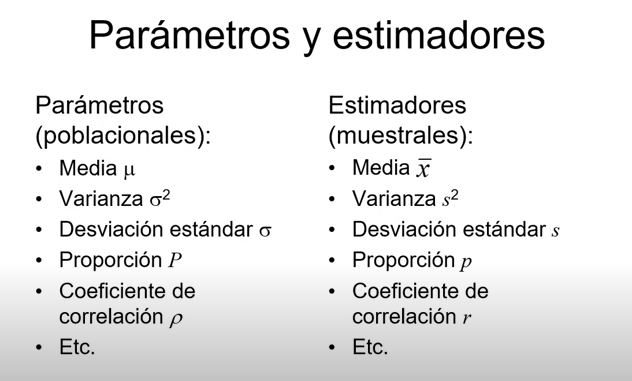

Es claro que vamos a tener una diferencia con el parametro poblacional. Para nuestro caso del **I.C.**; esta variaciones la conoceremos como **el error estandar** *(este varia deacuerdo al parametro que estemos desarrollando)*. Pero por lo general lo estaremos notando de la siguiente forma:

$$ \text{Estimacio puntual ± (Valor critico) * Error estandar} $$

En si es la desviacion estandar que tenga el estimador muestral.

Para el caso del **Nivel de confianza** sera la probabilidad en la que no falle la estimacion de nuestro **I.C.** y loa veremos como: $1 - \alpha$ y con esto podemos determinar cuales son los valores criticos *(percentiles)* que dan forma a la distribucion de nuestro estimador o Parametro *(ya sea como lo encontremos en la situacion)*

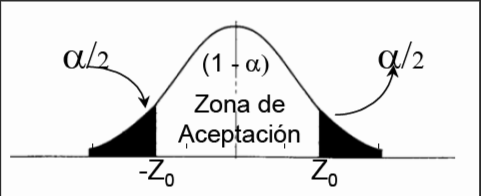

Vemos algunos ejemplo que nos ofrece los intervalos de confianza y como se calculan...

In [ ]:
# Traemos las paqueterias clasicas para la graficacion y los calculos...

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

Existe una gran variedad de **I.C.** que establecer los valores que tome los Parametros Poblacionales *(ver el PDF)*; solo veremos algunos casos...

## Intervalo de Confianza para la media de una distribución normal ($\sigma$ conocida)

Sea $X_1, \dots, X_n$ una m.a. $X_i \sim \mathcal{N}(\mu, \sigma^2)$. Entonces si queremos realizar el **I.C.** para la media poblacional seria por el siguientes estimador: $\bar{X}$ pero por el **Teorema del limite Central**

$$ \bar{X} \sim \mathcal{N}(\mu, \frac{\sigma^2}{n}) $$

Si lo estandarizamos...

$$ Z = \frac{\bar{X} - \mu}{\sigma / \sqrt{n}} \sim \mathcal{N}(0,1) $$

**Nota:** si nos comentan que hay un ***Nivel de significancia***; lo interpretaremos como el error que se espera y no es mas que $\alpha$.

El intervalo de confianza que generamos, se basa en que:

$$ \mathbb{P}\left( -z_{\alpha/2} < \frac{\bar{X} - \mu}{\sigma / \sqrt{n}} < z_{\alpha/2} \right) = \mathbb{P}\left( \bar{X} - z_{\alpha/2} \frac{\sigma}{\sqrt{n}} < \mu < \bar{X} + z_{\alpha/2} \frac{\sigma}{\sqrt{n}} \right)
= 1 - \alpha $$

Ya con esto podemos ver cual es el intervalo de confianza...

El intervalo del $(1 - \alpha) \cdot 100\%$ de confianza para $\mu$ (con $\sigma$ conocida) es:

$$
\left( \bar{X} - z_{\alpha/2} \frac{\sigma}{\sqrt{n}}, \quad \bar{X} + z_{\alpha/2} \frac{\sigma}{\sqrt{n}} \right)
$$

donde:

- $\bar{X}$ es nuestro estimador puntual.
- $\sigma$ = desviación estándar.
- $\frac{\sigma}{\sqrt{n}}$ = error estándar de la media.
- $z_{\alpha/2}$ el valor critico *(determina el nivel de confianza)*.

**Observación:**

- A mayor $n$, menor es el error estándar, y el intervalo de confianza es más pequeño.
- Esto hace que se acerque más a la media $\mu$, es decir, que haya menor variación.
- El intervalo está centrado en $\bar{X}$.


### **Ejemplos:**

$ \color{red}{\text{Ejemplo 1:}} $

Para tratar de estimar la media de consumo por cliente en un gran restaurante, se reunieron datos de una muestra de 49 clientes durante 3 semanas.

**a)** Supongamos que la **desviación estándar de la población** es de $\$2.50$. ¿Cuál es el error estándar de la media?

**b)** Con un nivel de confianza del $95\%$, ¿cuál es el margen de error?

**c)** Si la **media de la muestra** es de $\$22.60$, cuál es el intervalo de confianza del $95\%$ para la media de la población?

In [ ]:
# Datos
n=49
sigma = 2.50
media_muestral = 22.60
confianza = 0.95

# a) Error estándar de la media
error_estandar = sigma / np.sqrt(n)
print(f" a) Error estándar de la media: {error_estandar:.2f}")

# b) Margenes de error
z = st.norm.ppf(1-(1-confianza) / 2)
margen_error = z * error_estandar
print(f" b) Margen de error con 95% de confianza: {margen_error:.2f}")

# c) ;a construccion del IC
limite_inferior = media_muestral - margen_error
limite_superior = media_muestral + margen_error
print(f" c) Intervalo de confianza del 95%: ({limite_inferior:.2f},{limite_superior:.2f})")

 a) Error estándar de la media: 0.36
 b) Margen de error con 95% de confianza: 0.70
 c) Intervalo de confianza del 95%: (21.90,23.30)


**Observacion:** Notemos que si tenemos un Nivel del Confianza $1 - \alpha=.95$ y se contempla una distribucion Normal Estandar; el valor critico sera de esta forma:

$$ z_{\alpha/2} = z_{0.025} = 1.96 $$

$ \color{red}{\text{Ejemplo 2:}} $

Supongamos que se toma una muestra aleatoria de 100 personas para estimar la media del peso de una población, y se obtiene que la media muestral es de $70$ kg con una desviación estándar que es conocida de $10$ kg. Para un nivel de confianza del $95\%$, calcular el intervalo de confianza

In [ ]:
# Datos
n = 100
media_muestral = 70
sigma = 10
nivel_confianza = 0.95
error_estandar = sigma / np.sqrt(n)

Para este solucion del problema vamos a utilizar una funcion de **Calculo de Intervalo** por la paqueteria *scipy.stats* con la siguiente estructura...

Utilizaremos la función **"scipy.stats.norm.interval"**

$$ \text{scipy.stats.norm.interval(Nivel de confianza, loc = \mu, scale = \sigma)} $$

In [ ]:
intervalo = st.norm.interval(confidence = nivel_confianza, loc = media_muestral, scale = error_estandar)
print(f"Intervalo de confianza del 95% es: {intervalo}")

Intervalo de confianza del 95% es: (np.float64(68.04003601545995), np.float64(71.95996398454005))


Pasamos a ver como es la grafica que genera este intervalo de confianza...

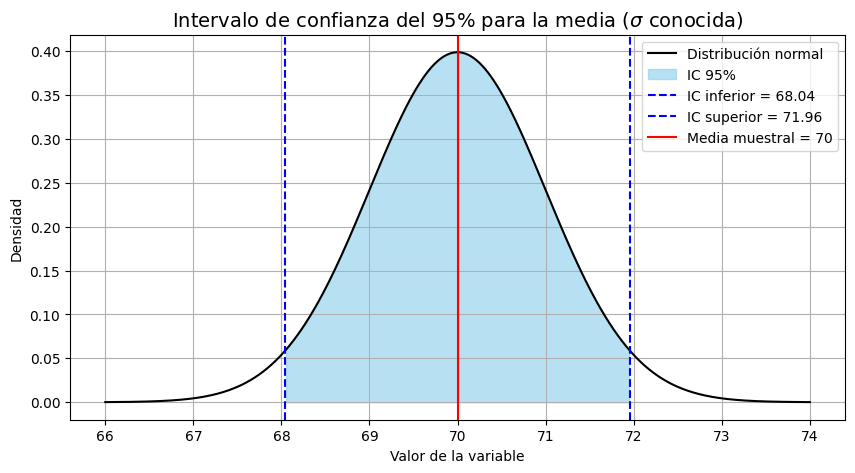

In [ ]:
# Puntos para graficar la curva normal
x = np.linspace(media_muestral - 4*error_estandar, media_muestral + 4*error_estandar, 500)
y = st.norm.pdf(x, loc=media_muestral, scale=error_estandar)

# Gráfica
plt.figure(figsize=(10, 5))
plt.plot(x, y, label='Distribución normal', color='black')

# Sombrear el intervalo de confianza
plt.fill_between(x, y, where=(x >= intervalo[0]) & (x <= intervalo[1]), color='skyblue', alpha=0.6, label='IC 95%')

# Líneas verticales
plt.axvline(intervalo[0], color='blue', linestyle='--', label=f'IC inferior = {intervalo[0]:.2f}')
plt.axvline(intervalo[1], color='blue', linestyle='--', label=f'IC superior = {intervalo[1]:.2f}')
plt.axvline(media_muestral, color='red', linestyle='-', label=f'Media muestral = {media_muestral}')

# el formto de la grafica
plt.title('Intervalo de confianza del 95% para la media ($\\sigma$ conocida)', fontsize=14)
plt.xlabel('Valor de la variable')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True)
plt.show()

## Intervalo de Confianza para la media $\mu$ de una distribución normal ($\sigma$ deconocida)


Sea $X_1, \dots, X_n$ una m.a. $X_i \sim \mathcal{N}(\mu, \sigma^2)$. Entonces como lo habiamos visto sabemos se distribuye el estadistico $\bar{X}$:

$$ \bar{X} \sim \mathcal{N}(\mu, \frac{\sigma^2}{n}) $$

Y al estandarizarlo...

-$$ Z = \frac{\bar{X} - \mu}{\sigma / \sqrt{n}} \sim \mathcal{N}(0,1) $$

Pero por degracia, no podemos utilizar nuestra $ \sigma $ *(ya que no fue proporcionado o los desconocesmos)*; por lo que lo reemplazamos con el estimador puntual $S$.

Esto provocaria que esto no estemos a una analisis de una Normal Estandar, sino a los parecido posible a este distribucion.

### $ \color{purple}{\text{Distribucion T-Students}} $

Sean las siguiente V.A.:

- $X \sim N(0,1)$  
- $Y \sim \chi^2(n - 1)$  

Entonces definimos la siguiente V.A. de la siguente forma:

$$ T = \frac{X \cdot \sqrt{n}}{\sqrt{\dfrac{Y}{n - 1}}} \sim t(n - 1) $$

Gráficamente, la distribución *t* tiene forma de campana, similar a la normal estándar, pero con colas más gruesas. A medida que $n \to \infty$, se aproxima a una normal estándar:

$$ \lim_{n \to \infty} t(n) = \mathcal{N}(0,1) $$

---

> 📌 Esta distribución es útil cuando se desconoce la varianza poblacional y se utiliza una estimación muestral.

---

**Observacion:** Si el tamaño de la muestra es menor a 30, se utiliza la $t$; de lo contrario se ocuparia la $z$

Veamos que tanto se Aproxima de la Normal Estandar que nos ofrece nueva Distribucion...

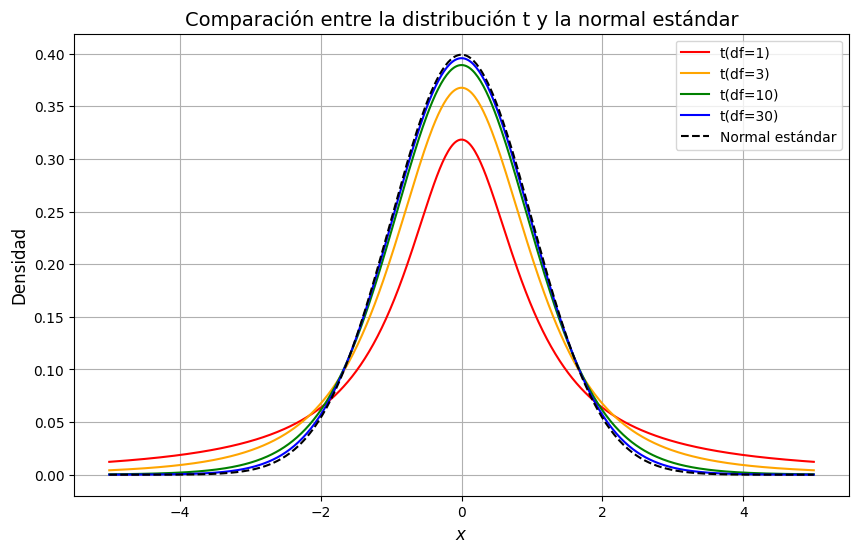

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, norm

# Valores de x para graficar
x = np.linspace(-5, 5, 500)

# Distribuciones t con diferentes grados de libertad
dfs = [1, 3, 10, 30]
colors = ['red', 'orange', 'green', 'blue']

plt.figure(figsize=(10, 6))

# Graficar curvas t
for df, color in zip(dfs, colors):
    plt.plot(x, t.pdf(x, df), label=f't(df={df})', color=color)

# Graficar la normal estándar
plt.plot(x, norm.pdf(x), 'k--', label='Normal estándar')

# Formato de la gráfica
plt.title('Comparación entre la distribución t y la normal estándar', fontsize=14)
plt.xlabel('$x$', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

Estadística t: 2.000
Valor crítico t (95%): ±2.131


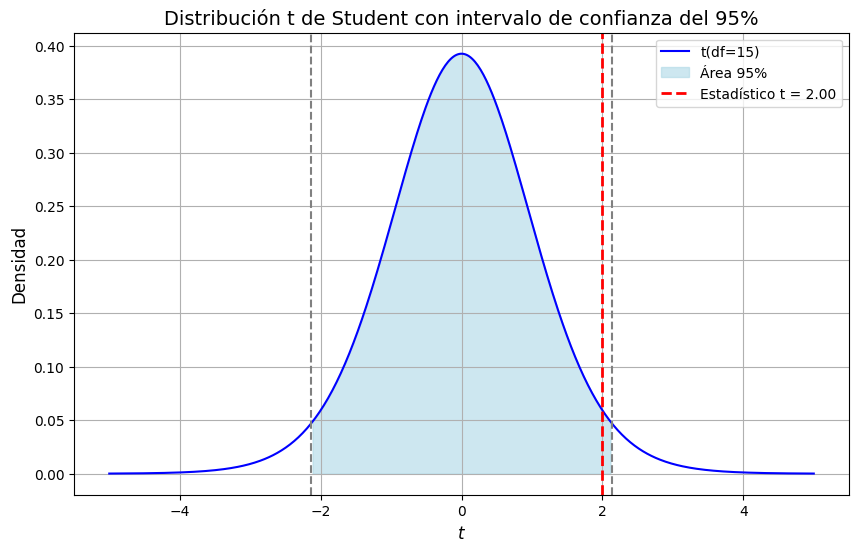

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

# Parámetros del ejemplo
n = 16                     # tamaño de muestra
df = n - 1                 # grados de libertad
media_muestral = 17.5
media_hipotetica = 16
desv_est_muestral = 3

# Estadística t
t_stat = (media_muestral - media_hipotetica) / (desv_est_muestral / np.sqrt(n))
print(f'Estadística t: {t_stat:.3f}')

# Intervalo de confianza del 95%
alpha = 0.05
t_critico = t.ppf(1 - alpha/2, df)
print(f'Valor crítico t (95%): ±{t_critico:.3f}')

# Gráfica
x = np.linspace(-5, 5, 500)
y = t.pdf(x, df)

plt.figure(figsize=(10,6))
plt.plot(x, y, label=f't(df={df})', color='blue')

# Rellenar área bajo la curva para el IC
plt.fill_between(x, y, where=(x >= -t_critico) & (x <= t_critico), color='lightblue', alpha=0.6, label='Área 95%')

# Línea para el valor de la estadística t calculada
plt.axvline(t_stat, color='red', linestyle='--', lw=2, label=f'Estadístico t = {t_stat:.2f}')
plt.axvline(-t_critico, color='gray', linestyle='--')
plt.axvline(t_critico, color='gray', linestyle='--')

# Detalles del gráfico
plt.title('Distribución t de Student con intervalo de confianza del 95%', fontsize=14)
plt.xlabel('$t$', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()


### Regresando a la interpretacion de nuestro **I.C.** *(con $\sigma$ desconocidad)*

Sea $X_1, \dots, X_n$ una m.a. $X_i \sim \mathcal{N}(\mu, \sigma^2)$. Entonces como lo habiamos visto sabemos se distribuye el estadistico $\bar{X}$:
Definimos el estadístico $T$ de la siguiente manera:

$$ T = \frac{\bar{X}-\mu}{s/\sqrt{n}} \sim t_{(n-1)} $$

El intervalo del $(1 - \alpha) \cdot 100\%$ de confianza para $\mu$ (con $\sigma$ desconocida) es:

$$ \left( \bar{X} - t_{\alpha/2} \frac{s}{\sqrt{n}}, \quad \bar{X} + t_{\alpha/2} \frac{s}{\sqrt{n}} \right) $$

donde:

- $s$ = desviación estándar muestral.
- $\frac{s}{\sqrt{n}}$ = error estándar de la media.
- $t_{\alpha/2}$ Sera nuestro Valor critico.  
- El intervalo está centrado en $\bar{X}$.

$ \color{red}{\text{Ejercicio 3:}} $

Supongamos que tenemos los siguientes datos:

$$ datos = [45, 55, 67, 45, 68, 79, 98, 87, 84, 82] $$

Calcular un intervalo de confianza para la media.

In [ ]:
# Datos del ejemplo
data = [45, 55, 67, 45, 68, 79, 98, 87, 84, 82]
confidence = 0.95       # Si no indica el valor de confianza; por default sera al 95%
gl = len(data) - 1      # grados de libertad

# Media y error estandar
mean = np.mean(data)
error_est = st.sem(data)

# Intervalo de confianza usando t de Student
intervalo = st.t.interval(confidence, gl, loc = mean, scale = error_est)

print(f"Media muestral: {mean:.2f}")
print(f"Error estandar: {error_est:.2f}")
print(f"El intervalo de confianza del 95% es: {intervalo}")

Media muestral: 71.00
Error estandar: 5.75
El intervalo de confianza del 95% es: (np.float64(58.000521742293884), np.float64(83.99947825770612))


## Intervalo de Confianza para la media $\sigma^2$ de una distribución normal (desconociendo a $\mu$)


Definimos el estadístico $\chi^2$ de la siguiente manera:

$$ \chi^2 = \frac{(n - 1) S^2}{\sigma^2} $$

El intervalo del $(1 - \alpha) \cdot 100\%$ de confianza para $\sigma^2$ (con una m.a. que se diatribuye como $N \sim (\mu,\sigma^2)$) es:

$$ \left( \frac{(n - 1) S^2}{\chi^2_{\alpha / 2; \, (n - 1)}} \, , \, \frac{(n - 1) S^2}{\chi^2_{1 - \alpha / 2, (n - 1)}} \right) $$

$ \color{red}{\text{Ejercicio 4:}} $

Los artículos de cerámica utilizados sobre velas electricas sobrecargadas se rompen con diferentes presiones. Supongamos que los datos provienen de una distribución normal.

La resistencia a la ruptura fue medida en una muestra de 100 artículos, y el promedio fue de $1750$ con un desviación estándar de $315.8$

**a)** Estimar con un nivel del confianza del $90\%$ a la media poblacional de la presión de la ruptura.

**b)** Estimar con un nivel del confianza del $90\%$ a la varianza poblacional.

In [ ]:
# datos
n = 100
media_muestral = 1750
desv_estandar_muestral = 315.8
confianza = 0.90

In [ ]:
# a) Usar la normal ya que el tamaño de la muestra es grande usaremos el I.C. ANTERIOR
error_est = desv_estandar_muestral / np.sqrt(n)
error_est
intervalo_media = st.norm.interval(confidence=confianza, loc = media_muestral, scale = error_est)
print(f"El intervalo de confianza del 90% es: {intervalo_media}")

El intervalo de confianza del 90% es: (np.float64(1698.0555224608725), np.float64(1801.9444775391275))


Para el caso del inciso **b)** tendriamos que ver como es el comportamiento de la $\sigma^2$ *(La desviacion estandar directamente ya que no es lo mismo que sacarle el cuadrado)*; para ello tendriamos que ver la siguiente **I.C.**. esto es porque ya esta especializada para una m.a. que se distribuye como $N \sim (\mu, \sigma^2)$...

### $ \color{purple}{\text{Distribución Ji-cuadrada (Chi-cuadrada)}} $

Sea la siguiente V.A.:

- $ X \sim \mathcal{N}(0,1) $  
- $ X^2 \sim \chi^2_1 $

Y recordemos que de como lo habiamos definido de su forma generalizacion:

$$
\sum_{i=1}^{n} X_i^2 \sim \chi^2_n
$$

La distribución $\chi^2_k$ surge como la suma de los cuadrados de $k$ variables normales estándar independientes.

---

> 📌 Esta distribución es útil cuando se desconoce la varianza poblacional y pero se sabe la m.a. tiene una distribucion Normal.

---

Veamos como es el comportamiento de la chi-cuadrada de forma ilustrativa...

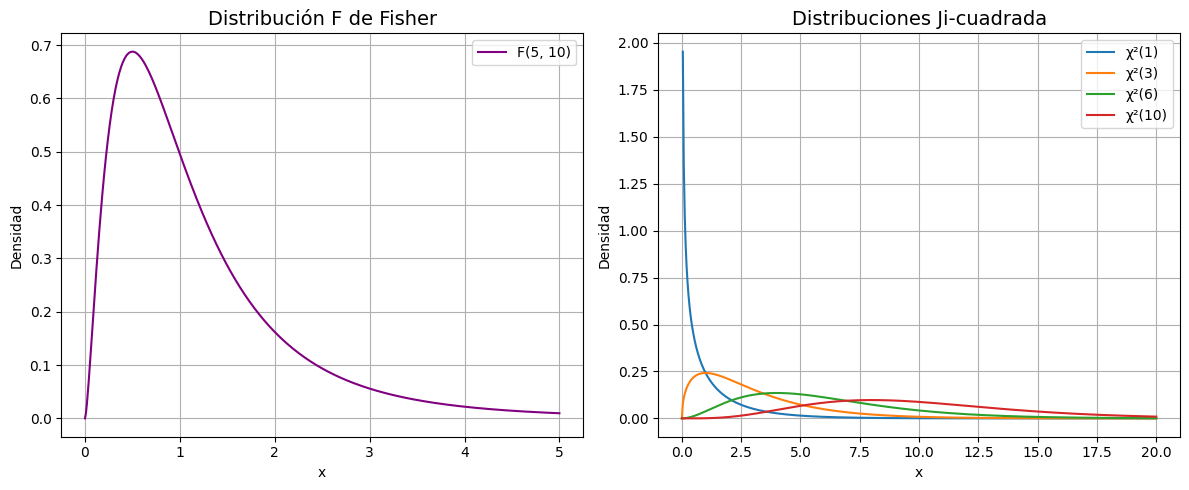

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f, chi2

# Rango de valores para las gráficas
x_f = np.linspace(0, 5, 500)
x_chi = np.linspace(0, 20, 500)

# --- Distribución F de Fisher ---
df1, df2 = 5, 10
f_dist = f.pdf(x_f, df1, df2)

plt.figure(figsize=(12, 5))

# Gráfica de F
plt.subplot(1, 2, 1)
plt.plot(x_f, f_dist, label=f'F({df1}, {df2})', color='purple')
plt.title('Distribución F de Fisher', fontsize=14)
plt.xlabel('x')
plt.ylabel('Densidad')
plt.grid(True)
plt.legend()

# --- Distribuciones Ji-cuadrada ---
df_chi_list = [1, 3, 6, 10]

plt.subplot(1, 2, 2)
for df in df_chi_list:
    plt.plot(x_chi, chi2.pdf(x_chi, df), label=f'χ²({df})')
plt.title('Distribuciones Ji-cuadrada', fontsize=14)
plt.xlabel('x')
plt.ylabel('Densidad')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


### Regresando a la interpretacion de nuestro **I.C.** *(con $\sigma$ desconocidad y m.a. que se distribuye como Normal)*

In [ ]:
from scipy.stats import chi2

# b) Intervalo de confianza para la varianza (usar chi-cuadrada)
alpha = 1-confianza
gl = n-1
s2 = desv_estandar_muestral**2

#Cuantiles de la chi-cuadrada
chi2_inf = st.chi2.ppf(alpha / 2,df=gl)
chi2_sup = st.chi2.ppf(1- alpha / 2,df=gl)

# Intervalo de confianza
intervalo_varianza = ((gl * s2) / chi2_sup, (gl * s2) / chi2_inf )
print(f"El intervalo de confianza del 90% es: {intervalo_varianza}")

#Otra forma
chi2_low, chi2_high = chi2.interval(confianza,df=gl)
intervalo_varianza1 = ((gl * s2) / chi2_high, (gl * s2) / chi2_low )
print(f"El intervalo de confianza del 90% es: {intervalo_varianza1}")


El intervalo de confianza del 90% es: (np.float64(80123.48643850331), np.float64(128146.71537457063))
El intervalo de confianza del 90% es: (np.float64(80123.48643850331), np.float64(128146.71537457063))


## Intervalo de confianza para la diferencia de medias de dos distribuciones normales $\sigma^2$ de una distribución normal (conociendo $\sigma^2_1$ y $\sigma^2_2$)

Supongamos que tenemos dos m.a. $A$ y $B$ de una poblacion que deseamos parametrizar:

*   Para el caso de la muestra aleatoria $A$

Sea $X_1, \dots, X_n$ m.a.; es claro que para el estadistico $\bar{X_A}$ se distribuye como: $ \sim N(\mu_A, \frac{\sigma^2}{n})$

*   Para el caso de la muestra aleatoria $B$

Sea $X_1, \dots, X_m$ m.a.; es claro que para el estadistico $\bar{X_B}$ se distribuye como: $ \sim N(\mu_B, \frac{\sigma^2}{n})$

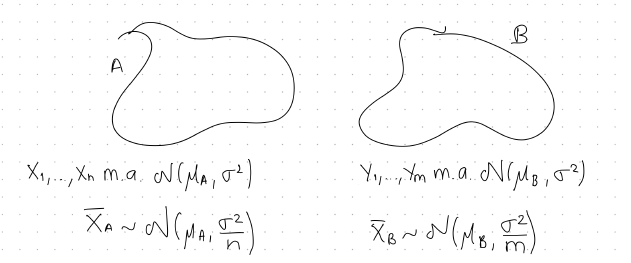

Como sabemos como son $\sigma^2_1$ y $\sigma^2_2$, deifnimos el siguiente estadistico $D$ tal que...

$$ D = \bar{X}_A - \bar{X}_B \sim N \left( \mu_A - \mu_B, \sigma^2 \left( \frac{1}{n} + \frac{1}{m} \right) \right) $$

El intervalo del $(1 - \alpha) \cdot 100\%$ de confianza para $\mu_A - \mu_B$ (con las $\sigma^2$ de ambas poblaciones) son:

$$ \left( \left( \bar{X}_A - \bar{X}_B \right) - Z_{1 - \alpha/2} \cdot \sigma \sqrt{ \frac{1}{n} + \frac{1}{m}}, \left( \bar{X}_A - \bar{X}_B \right) + Z_{1 - \alpha/2} \cdot \sigma \sqrt{ \frac{1}{n} + \frac{1}{m}} \right) $$

$ \color{red}{\text{Ejercicio 5:}} $

El artículo "*Evaluation of a Ventilation Strategy to Prevent Barotrauma in Patients at High Risk for Acute Respiratory Distress Syndrome*" reportó sobre un experimento con 120 pacientes con anestesistas en cuidados intensivos (UCI), los cuales fueron divididos al azar en dos grupos, donde cada uno esta compuesto por 60 pacientes.

- Grupo A: promedio de permanencia = 14.1 horas
- Grupo B: promedio de permanencia = 17.5 horas
- Desviación estándar en ambos = 5.1 hrs

Encontrar un intervalo del $95\%$ de confianza para la diferecia de medias poblacionales: $(\mu_A - \mu_B)$  

In [ ]:
#Datos
n1 = 60
n2 = 60

media1 = 14.1
media2 = 17.5

sigma = 5.1   # para ambas poblaciones

confianza = 0.95
alpha = 1-confianza

#valor critico
z = st.norm.ppf(1 - alpha / 2)

#Error estandar
error_est = sigma * np.sqrt(1/n1 + 1/n2)
dif_medias = media1 - media2
margen_error = z *error_est

#Creamos loos limites del intervalo
lim_inf = dif_medias - margen_error
lim_sup = dif_medias + margen_error

print(f"Diferencia de las medias: {dif_medias:.2f}")
print(f"Intervalo de confianza del 95%: ({lim_inf:.2f},{lim_sup:.2f})")

Diferencia de las medias: -3.40
Intervalo de confianza del 95%: (-5.22,-1.58)


## Intervalo de confianza para la proporcion $P$ (Desconociendo a "p")

Sea una m.a. que curiosamente se comporte como una $ Bin(n,p) $ y queremos conocer ESTIMAR a **la probabilidad de exito** de una poblacion; como lo desconocemos usaremos el estadistico $\bar{X}$.

Como ya sabemos que para $ \bar{X} \sim N(\mu, \frac{\sigma^2}{n}) $; pero pasa algo curioso que lo arreglamos mas adelante..

El intervalo del $(1 - \alpha) \cdot 100\%$ de confianza para $P$ (conociendo el tamano de la muestra) son:

$$ I.C. = \left( \hat{p} - Z_{\frac{\alpha}{2}} * \sqrt{\frac{\hat{p} (1 - \hat{p})}{n}}, \hat{p} + Z_{\frac{\alpha}{2}} * \sqrt{\frac{\hat{p} (1 - \hat{p})}{n}} \right) $$

**Observacion:**

*   Siempre y cuando se cumpla los siguientes condiciones:
    *   $n\hat{p} > 5$
    *   $n(\hat{p} - 1) > 5$
*   Es curioso pensar el hecho de que si deseamos calcular $P$ necesitemos una $\hat{p}$, que no es nuestro estimador. Pero no hay que espantarnos ya que:

$$ \hat{p} = \frac{\text{total de casos}}{n} \approx \frac{\sum x_i}{n} = \bar{X} $$



$ \color{red}{\text{Ejercicio 6:}} $

En una encuesta de realizada en la Universidad; 225 estudiantes son seleccionados al azar de los que toman cálculo y se les pregunta si cálculo es su materia favorita. 100 estudiantes responden que el cálculo es su materia favorita.

Proporcione un intervalo de confianza del 95 %  para la proporción de todos los estudiantes que toman cálculo y que la consideran su materia favorita.  

Ya teniendo este resultado vamos contruir nuestro intervalo de confianza...

Sea los siguiente terminos:

- $n = 225$ *(Tamaño de la muestra)*
- $\hat{p} = 100 / 225$ *(Proporcion estimada)*
- $1 - \alpha = .95$  *(Nive de confianza)*

Con esto podemos ver como que nuestro $ SE =  \sqrt{\frac{\hat{p} (1 - \hat{p})}{n}} $

In [ ]:
n = 225
p_hat = 100 / n
alpha = 0.95
SE = round((p_hat * (1 - p_hat) / n) ** 0.5, 6)

print(SE)

0.033127


Para el caso del $Z_{\frac{\alpha}{2}}$ *(el valor critico de N $\sim$ (0,1) )* sera del $1.96$. Pasemos a los limites del $I.C.$

In [ ]:
limite_inferior = 100 - 1.96 * SE
limite_superior = 100 + 1.96 * SE

Podemos decir que $ \hat{p} $ de los alumnos que tiene una preferencia a la materia de calculo estaria osilando de la siguiente forma...

In [ ]:
print("El intervalo de confianza para \p sera de: (", limite_inferior, ",", limite_superior, ")" )

El intervalo de confianza para \p sera de: ( 99.93507108 , 100.06492892 )
